<a href="https://colab.research.google.com/github/Yashika84/Wildfire_Boundary_Detection/blob/main/DAA_PBL_Wildfire_detection_boundary.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

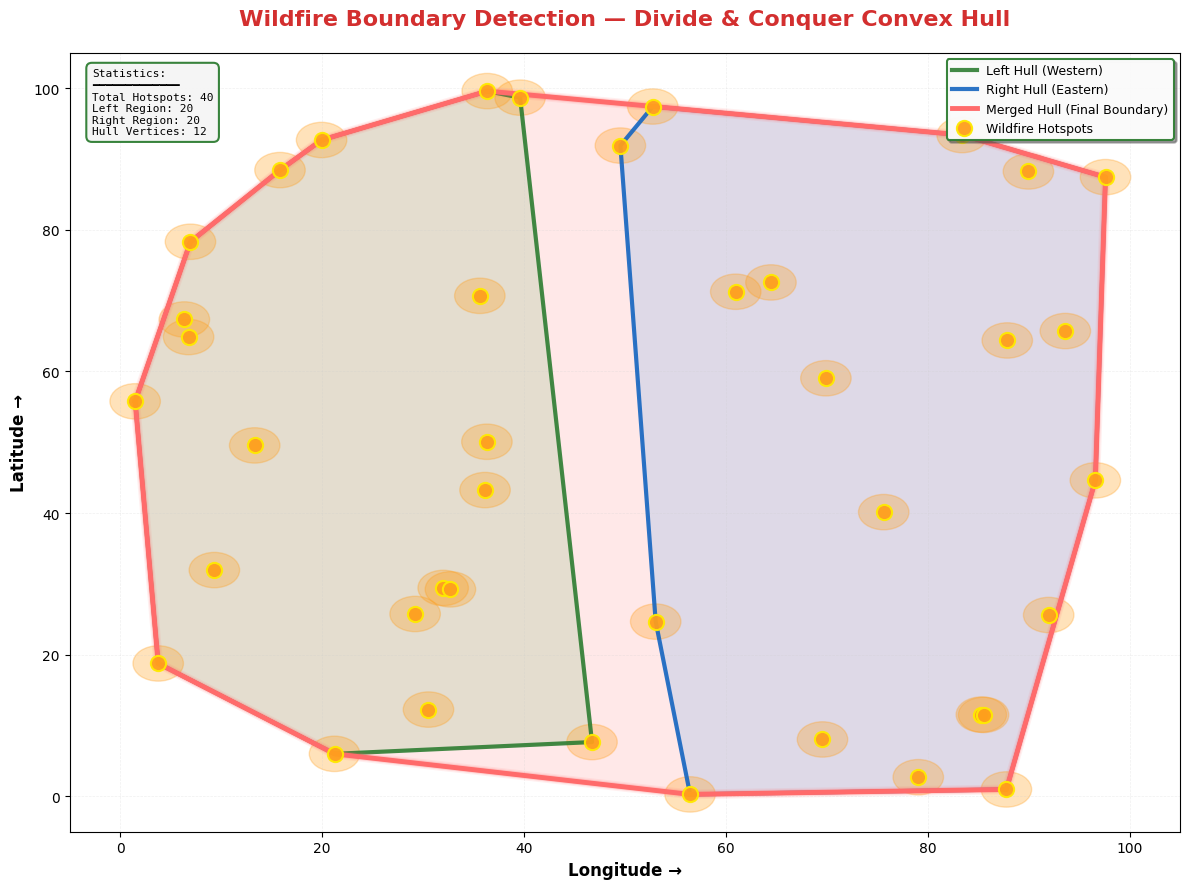

   WILDFIRE BOUNDARY DETECTION 
  Using Divide & Conquer Convex Hull Algorithm
  >> Left Hull: Western Fire Boundary (20 hotspots)
  >> Right Hull: Eastern Fire Boundary (20 hotspots)
  >> Merged Hull: Total Wildfire Spread Region
   Total Hotspots Detected: 40
   Convex Hulls Computed Successfully


In [ ]:
# ===============================================================
# DAA PBL: Wildfire Boundary Detection using Convex Hull
# ---------------------------------------------------------------
# Aim: To detect the outer boundary of wildfire hotspots using
# Divide and Conquer Convex Hull method for disaster analysis

import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import ConvexHull
from matplotlib.patches import Circle

# Generate random wildfire hotspot coordinates
# ---------------------------------------------------------------
def generate_hotspots(n=40, x_range=(0, 100), y_range=(0, 100)):
    return np.array([(random.uniform(*x_range), random.uniform(*y_range)) for _ in range(n)])

# Compute Convex Hull for any given set of points
# ---------------------------------------------------------------
def compute_hull(points):
    if len(points) < 3:
        return points
    hull = ConvexHull(points)
    hull_points = points[hull.vertices]
    return np.concatenate([hull_points, hull_points[:1]])

# Divide & Conquer Convex Hull Visualization
# ---------------------------------------------------------------
if __name__ == "__main__":
    # Generate random hotspots
    points = generate_hotspots(40)
    points = points[np.argsort(points[:, 0])]  # Sort by X-axis for division

    # Divide data into Left and Right halves
    mid = len(points) // 2
    left_points = points[:mid]
    right_points = points[mid:]

    # Compute hulls
    left_hull = compute_hull(left_points)
    right_hull = compute_hull(right_points)
    merged_hull = compute_hull(points)

    # Visualization
    # ----------------------------------------------------------
    plt.style.use('default')
    fig, ax = plt.subplots(figsize=(12, 9))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Title
    ax.set_title("Wildfire Boundary Detection — Divide & Conquer Convex Hull",
                 fontsize=16, fontweight='bold', color='#d32f2f', pad=20,
                 family='sans-serif')

    ax.set_xlim(-5, 105)
    ax.set_ylim(-5, 105)
    ax.set_xlabel("Longitude →", fontsize=12, color='black', fontweight='bold')
    ax.set_ylabel("Latitude →", fontsize=12, color='black', fontweight='bold')

    # grid
    ax.grid(True, linestyle='--', alpha=0.3, color='#cccccc', linewidth=0.5)
    ax.tick_params(colors='black', labelsize=10)

    # Left hull
    # -----------------------------------------------------------
    ax.plot(left_hull[:, 0], left_hull[:, 1], color='#2e7d32',
            linewidth=3, label="Left Hull (Western)", linestyle='-', alpha=0.9)
    ax.fill(left_hull[:, 0], left_hull[:, 1], color='#66bb6a', alpha=0.2)

    # Right hull
    # -----------------------------------------------------------
    ax.plot(right_hull[:, 0], right_hull[:, 1], color='#1565c0',
            linewidth=3, label="Right Hull (Eastern)", linestyle='-', alpha=0.9)
    ax.fill(right_hull[:, 0], right_hull[:, 1], color='#42a5f5', alpha=0.2)

    # Merged Hull
    # -----------------------------------------------------------
    for width, alpha in [(7, 0.1), (5, 0.2), (3, 0.4)]:
        ax.plot(merged_hull[:, 0], merged_hull[:, 1], color='#ff6b6b',
                linewidth=width, alpha=alpha)

    ax.plot(merged_hull[:, 0], merged_hull[:, 1], color='#ff6b6b',
            linewidth=3.5, label="Merged Hull (Final Boundary)", linestyle='-')
    ax.fill(merged_hull[:, 0], merged_hull[:, 1], color='#ff6b6b', alpha=0.15)

    # Plotting wildfire hotspots
    # -----------------------------------------------------------

    for point in points:
        circle = Circle(point, 2.5, color='#ff9f1c', alpha=0.3)
        ax.add_patch(circle)

    # hotspot markers
    ax.scatter(points[:, 0], points[:, 1],
               s=120, c='#ff9f1c', edgecolor='#ffea00',
               linewidth=1.5, alpha=0.95, label="Wildfire Hotspots",
               marker='o', zorder=5)

    # Enhanced legend
    # -----------------------------------------------------------
    legend = ax.legend(loc='upper right', fontsize=9, frameon=True,
                      fancybox=True, shadow=True, framealpha=0.95)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_edgecolor('#2e7d32')
    legend.get_frame().set_linewidth(1.5)

    for text in legend.get_texts():
        text.set_color('black')

    # statistics box
    # -----------------------------------------------------------
    stats_text = f"Statistics:\n" \
                 f"━━━━━━━━━━━━━\n" \
                 f"Total Hotspots: {len(points)}\n" \
                 f"Left Region: {len(left_points)}\n" \
                 f"Right Region: {len(right_points)}\n" \
                 f"Hull Vertices: {len(merged_hull)-1}"

    ax.text(0.02, 0.98, stats_text,
            transform=ax.transAxes,
            fontsize=8,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5f5f5',
                     edgecolor='#2e7d32', alpha=0.95, linewidth=1.5),
            color='black',
            family='monospace')

    plt.tight_layout()
    plt.show()

    print("="*55)
    print("   WILDFIRE BOUNDARY DETECTION ")
    print("  Using Divide & Conquer Convex Hull Algorithm")
    print("="*55)
    print(f"  >> Left Hull: Western Fire Boundary ({len(left_points)} hotspots)")
    print(f"  >> Right Hull: Eastern Fire Boundary ({len(right_points)} hotspots)")
    print(f"  >> Merged Hull: Total Wildfire Spread Region")
    print("="*55)
    print(f"   Total Hotspots Detected: {len(points)}")
    print(f"   Convex Hulls Computed Successfully")
